https://www.youtube.com/watch?v=2IHA8QgKwbw&list=PLEuhkeqNvDnL-sRcMeA814I9SG3ufwXUd&index=1

In [1]:
import nltk

nltk.download('wordnet')

from nltk.corpus import wordnet as wn

synsets = wn.synsets('hallucination')
print(synsets)

[nltk_data] Downloading package wordnet to /home/cruz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[Synset('hallucination.n.01'), Synset('delusion.n.02'), Synset('hallucination.n.03')]


In [2]:
from nltk.corpus import wordnet as wn

dog = wn.synsets('dog')[0]
canine = wn.synset('canine.n.02')

lca = dog.lowest_common_hypernyms(canine)

print(f"The LCA of 'dog' and 'canine' is: {lca[0].name()}")

lca = canine.lowest_common_hypernyms(dog)

print(f"The LCA of 'canine' and 'dog' is: {lca[0].name()}")

The LCA of 'dog' and 'canine' is: canine.n.02
The LCA of 'canine' and 'dog' is: canine.n.02


In [3]:
from nltk.corpus import wordnet as wn

dog = wn.synsets('dog')[0]
cat = wn.synsets('cat')[0]

lca = dog.lowest_common_hypernyms(cat)

print(f"The LCA of 'dog' and 'cat' is: {lca[0].name()}")

lca = cat.lowest_common_hypernyms(dog)

print(f"The LCA of 'cat' and 'dog' is: {lca[0].name()}")

The LCA of 'dog' and 'cat' is: carnivore.n.01
The LCA of 'cat' and 'dog' is: carnivore.n.01


In [4]:
from nltk.corpus import wordnet as wn

dog = wn.synsets('dog')[0]
chair = wn.synsets('chair')[0]

lca = dog.lowest_common_hypernyms(chair)

print(f"The LCA of 'dog' and 'chair' is: {lca[0].name()}")

lca = chair.lowest_common_hypernyms(dog)

print(f"The LCA of 'chair' and 'dog' is: {lca[0].name()}")

The LCA of 'dog' and 'chair' is: whole.n.02
The LCA of 'chair' and 'dog' is: whole.n.02


בגלל שכלב הוא יצור טבעי ומכונית היא חפץ מלאכותי, אין להם כמעט שום דבר משותף. כדי למצוא להם אבא קדמון, האלגוריתם נאלץ לטפס כמעט עד לראש העץ, עד לנקודה שבה שניהם פשוט מסווגים כ"אובייקטים פיזיים שלמים", רגע לפני שהעץ מתפצל ליצורים חיים מול חפצים דוממים.

In [5]:
from nltk.corpus import wordnet as wn

def distance_to_lca(synset1, synset2):
    lca = synset1.lowest_common_hypernyms(synset2)[0]
    
    return synset1.shortest_path_distance(lca)

dog = wn.synsets('dog')[0]
cat = wn.synsets('cat')[0]
chair = wn.synsets('chair')[0]
canine = wn.synset('canine.n.02') 

print(f"Distance between dog and canine: {distance_to_lca(dog, canine)}")
print(f"Distance between dog and cat: {distance_to_lca(dog, cat)}")
print(f"Distance between dog and chair: {distance_to_lca(dog, chair)}")

Distance between dog and canine: 1
Distance between dog and cat: 2
Distance between dog and chair: 5


https://www.youtube.com/watch?v=rldKl1CNx-A&list=PLGZqdNxqKzfYXTwYAZIlmjnQmrytCSR1J&index=1

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from nltk.corpus import wordnet as wn

G = nx.DiGraph()

def create_single_graph(word1, word2):
    G.clear()
    w1 = get_synset(word1)
    w2 = get_synset(word2)
    

    distance = distance_to_lca(w1, w2)
    print(f"Distance between {word1} and {word2}: {distance}")
    lca = w1.lowest_common_hypernyms(w2)[0]
    
    add_path(w1, lca)
    add_path(w2, lca)


    roots = [n for n, d in G.in_degree() if d == 0]
    root = roots[0]

    depths = nx.single_source_shortest_path_length(G, root)
    nx.set_node_attributes(G, depths, "layer")
    pos = nx.multipartite_layout(G, subset_key="layer")
    pos = {node: (coords[1], -coords[0]) for node, coords in pos.items()}
    plt.figure(figsize=(12, 7))

    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_color="lightblue", 
        node_size=500, 
        font_weight="bold",
        font_size=9,
        arrows=True,
        arrowsize=15
    )

    plt.margins(0.1)
    plt.show()

def get_synset(term):
    if '.' in term:
        return wn.synset(term)
    else:
        return wn.synsets(term)[0]
    
def distance_to_lca(synset1, synset2):
    lca = synset1.lowest_common_hypernyms(synset2)[0]
    return synset1.shortest_path_distance(lca)

def add_path(synset, lca):
    paths = synset.hypernym_paths()
    for path in paths:
        if lca in path:
            lca_index = path.index(lca)
            segment = path[lca_index:]
            
            for i in range(len(segment) - 1):
                parent = segment[i].name()
                child = segment[i+1].name()
                G.add_edge(parent, child)
            break

create_single_graph("dictionary","database")
create_single_graph("canine.n.02","cat")
create_single_graph("dog","chair")

AttributeError: 'Synset' object has no attribute 'longest_path_distance'

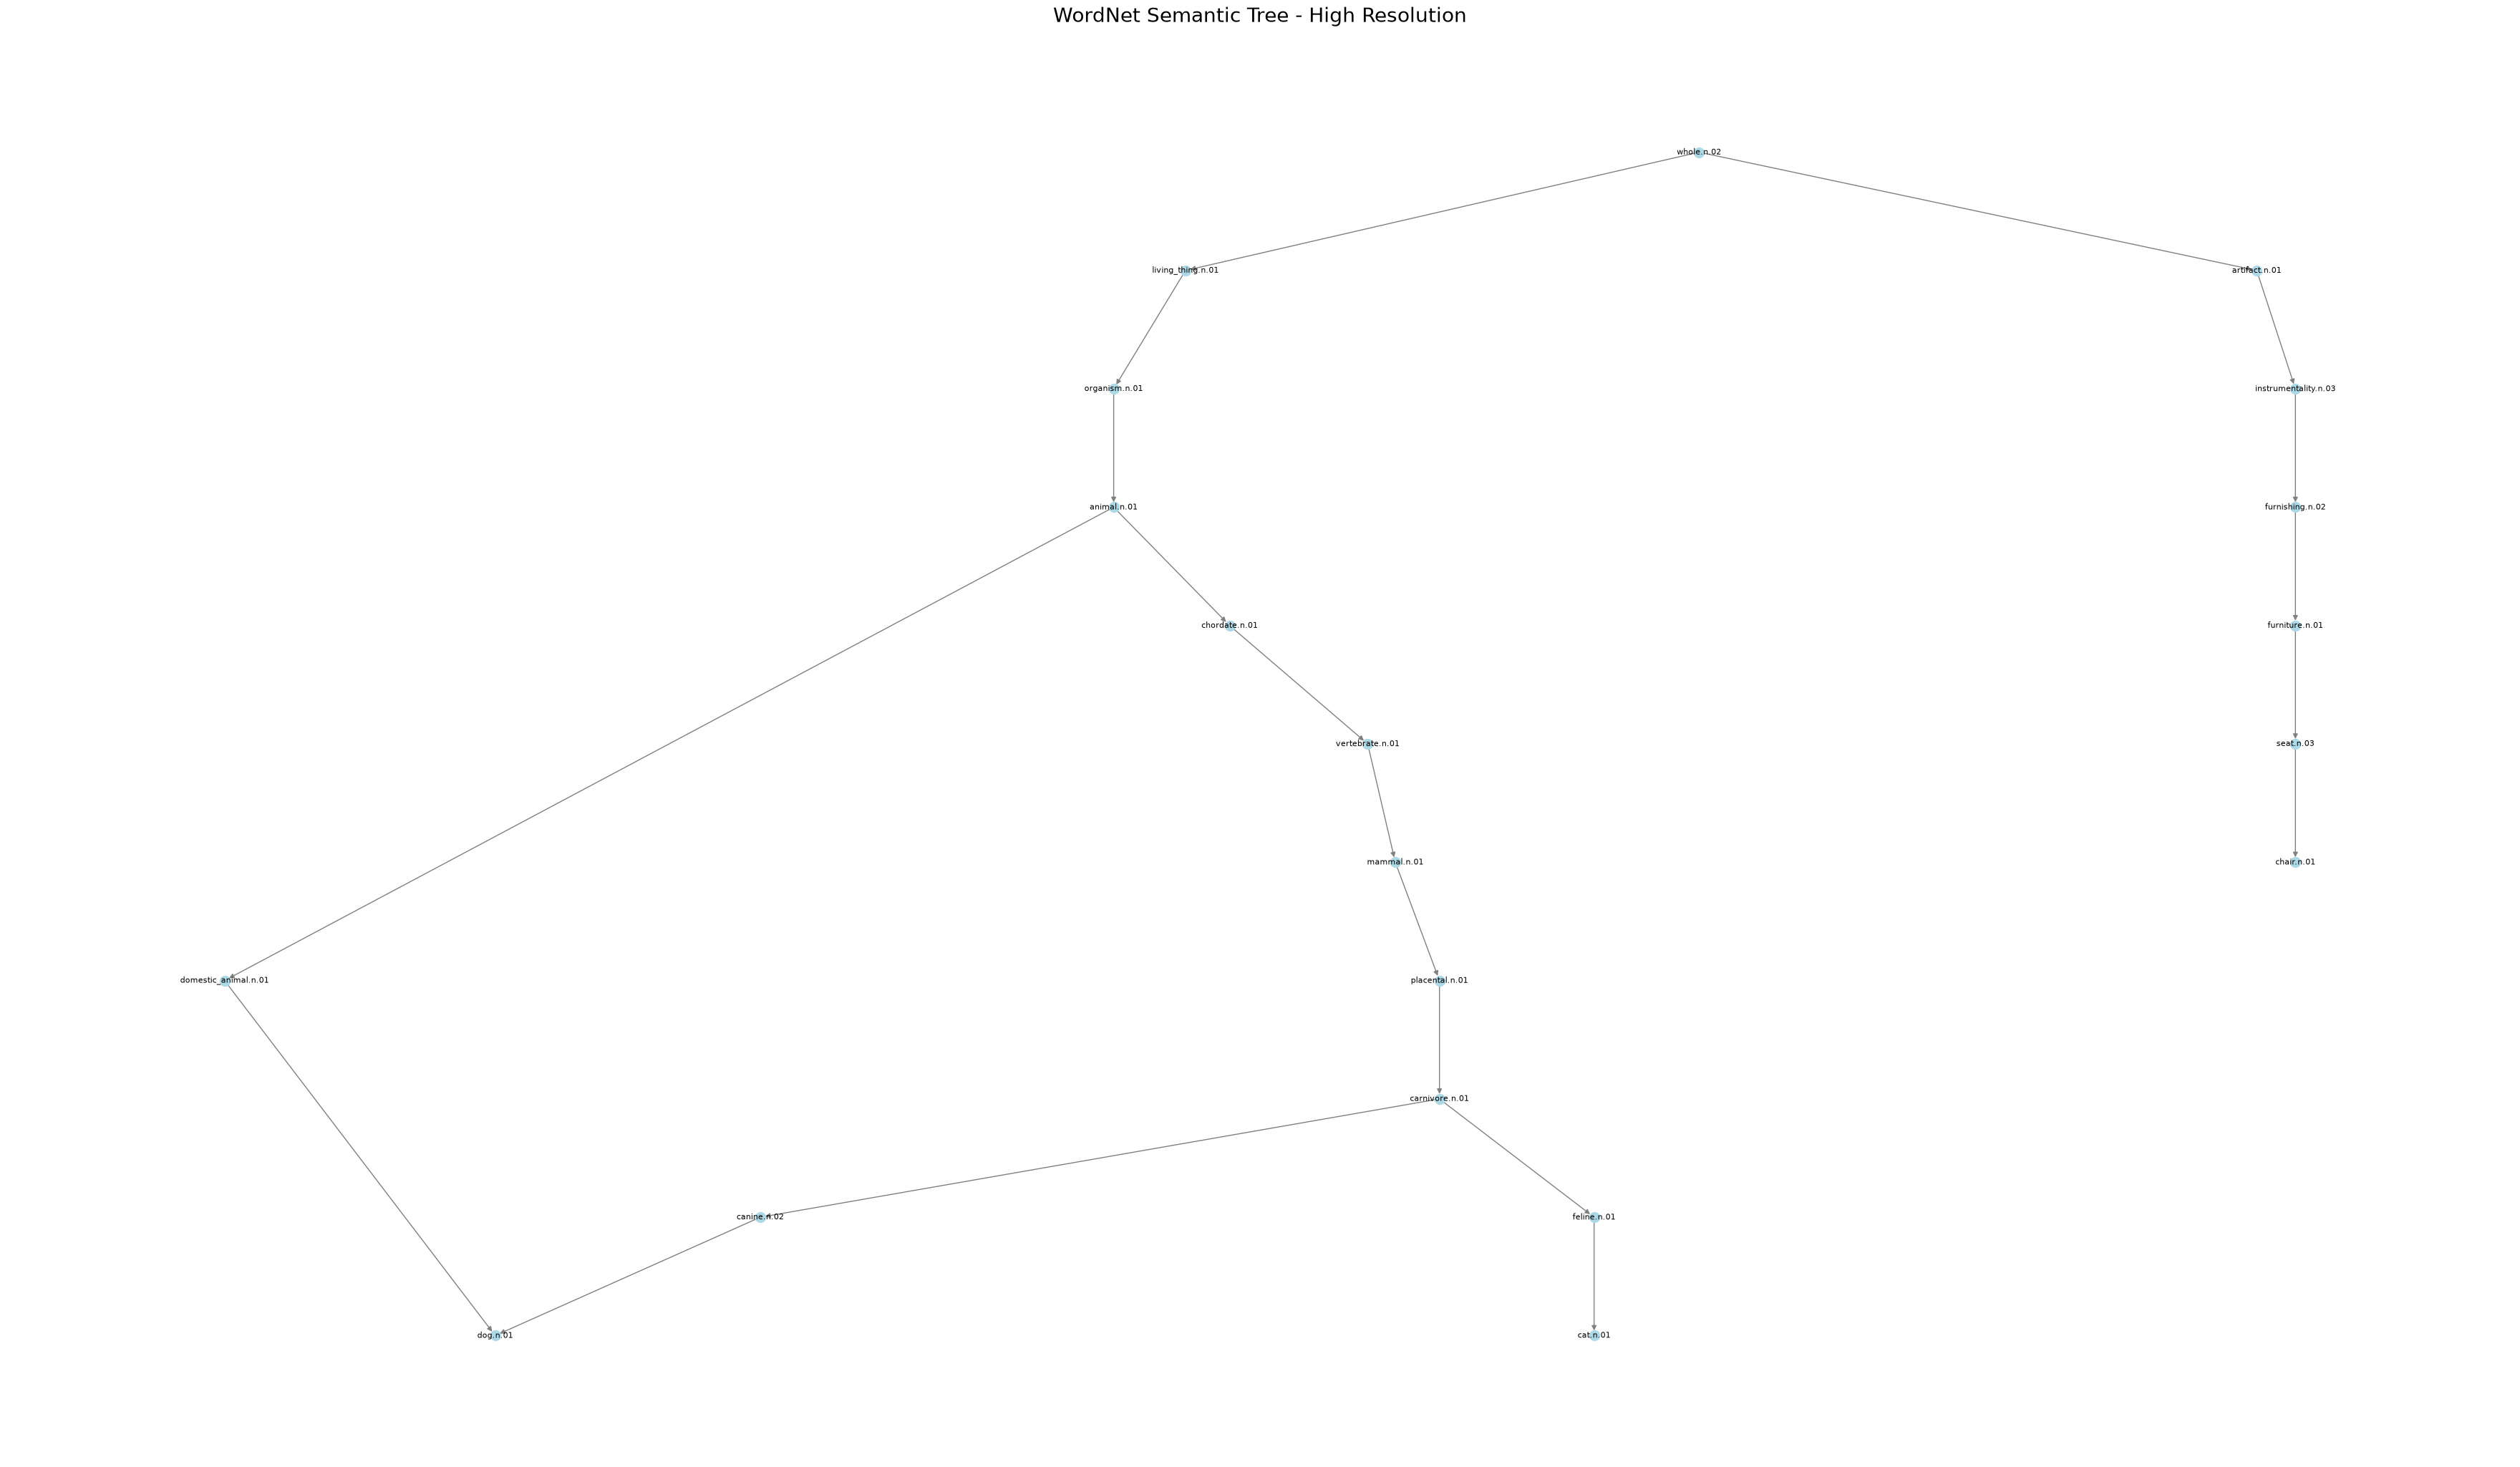

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from nltk.corpus import wordnet as wn
from networkx.drawing.nx_pydot import graphviz_layout

G = nx.DiGraph()

def get_synset(term):
    if '.' in term:
        return wn.synset(term)
    else:
        return wn.synsets(term)[0]

def distance_to_lca(synset1, synset2):
    lca = synset1.lowest_common_hypernyms(synset2)[0]
    return synset1.shortest_path_distance(lca)

def add_path(synset, lca):
    paths = synset.hypernym_paths()
    for path in paths:
        if lca in path:
            lca_index = path.index(lca)
            segment = path[lca_index:]
            
            for i in range(len(segment) - 1):
                parent = segment[i].name()
                child = segment[i+1].name()
                G.add_edge(parent, child)
            break

def add_word_pair(word1, word2):
    # שימוש בפונקציית העזר החדשה במקום לקרוא תמיד ל-[0]
    w1 = get_synset(word1)
    w2 = get_synset(word2)

    lca = w1.lowest_common_hypernyms(w2)[0]
    
    add_path(w1, lca)
    add_path(w2, lca)

def clean():
    """מנקה את הגרף מכל הצמתים והקשתות"""
    G.clear()

def draw_unified_tree():
    """מצייר את הגרף המאוחד בפריסה מרווחת ומותאמת לעצים גדולים"""
    
    # הגדרת כיוון העץ משמאל לימין ישירות על מאפייני הגרף
    G.graph['rankdir'] = 'LR'
    
    # חישוב הפריסה ללא פרמטר ה-args שגרם לשגיאה
    pos = graphviz_layout(G, prog="dot")

    # הגדלה משמעותית של משטח הציור
    plt.figure(figsize=(35, 20))

    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_color="lightblue", 
        node_size=100,      # הקטנת הבועות כדי לרווח
        font_weight="normal",
        font_size=8,        # הקטנת הפונט
        arrows=True,
        arrowsize=10,
        edge_color="gray"   # הבהרת הקשתות כדי שהטקסט יבלוט
    )

    plt.margins(0.05)
    plt.title("WordNet Semantic Tree - High Resolution", fontsize=20)
    
    # שמירת הגרף כקובץ תמונה ברזולוציה גבוהה
    plt.savefig("wordnet_tree_high_res.png", dpi=300, bbox_inches='tight')
    
    plt.show()

clean()

add_word_pair("dog", "cat")
add_word_pair("dog", "chair")
add_word_pair("chair", "cat")
# עכשיו הקריאה הזו תעבוד בצורה חלקה:
add_word_pair("dog", "canine.n.02")

draw_unified_tree()
clean()

In [8]:
import sys
import torch

print("Python path:", sys.executable)
print("Torch version:", torch.__version__)

Python path: /mnt/d/git/betterbot/.venv/bin/python
Torch version: 2.14.0+cu130


In [9]:
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Capability:", torch.cuda.get_device_capability())

GPU: NVIDIA GeForce RTX 5060 Ti
PyTorch: 2.14.0+cu130
CUDA: 13.0
CUDA available: True
Capability: (12, 0)


In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

local_model_path = "./Qwen-Model"

tokenizer = AutoTokenizer.from_pretrained(local_model_path)
model = AutoModelForCausalLM.from_pretrained(
    local_model_path,
    torch_dtype=torch.bfloat16,
    device_map="cuda:0"
)

/mnt/d/git/betterbot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 339/339 [02:19<00:00,  2.42it/s]


https://en.wikipedia.org/wiki/Computer_science

In [18]:
import nltk
from nltk.corpus import stopwords

factual_text = """
Computer science is the study of computation, information, and automation.
Computer science spans theoretical disciplines (such as algorithms, theory of computation, and information theory) to applied disciplines (including the design and implementation of hardware and software).
Computer science is generally considered an area of academic research and distinct from computer programming.
"""

factual_text2 ="""
WordNet is a lexical database of semantic relations between words that links words into semantic relations including synonyms, hyponyms, and meronyms. The synonyms are grouped into synsets with short definitions and usage examples. It can thus be seen as a combination and extension of a dictionary and thesaurus. Its primary use is in automatic text analysis and artificial intelligence applications. It was first created in the English language and the English WordNet database and software tools have been released under a BSD style license and are freely available for download. As of 2026, the project is no longer being developed. The online version is no longer available. Previous versions of the website described funding and staffing issues. There are several community-led projects actively maintaining a version of the dataset. Some efforts recognized by the project include the Open English Wordnet and the Global WordNet Association. WordNet was first created in 1985, in English only, in the Cognitive Science Laboratory of Princeton University under the direction of psychology professor George Armitage Miller. It was later directed by Christiane Fellbaum. The project was initially funded by the U.S. Office of Naval Research, and later also by other U.S. government agencies, including the DARPA, the National Science Foundation, the Disruptive Technology Office (formerly the Advanced Research and Development Activity) and REFLEX. George Miller and Christiane Fellbaum received the 2006 Antonio Zampolli Prize for their work with WordNet. The Global WordNet Association is a non-commercial organization that provides a platform for discussing, sharing and connecting WordNets for all languages in the world. Christiane Fellbaum and Piek Th. J. M. Vossen are its co-presidents. The database contains 155,327 words organized in 175,979 synsets for a total of 207,016 word-sense pairs; in compressed form, it is about 12 megabytes in size. It includes the lexical categories nouns, verbs, adjectives and adverbs but ignores prepositions, determiners and other function words. Words from the same lexical category that are roughly synonymous are grouped into synsets, which include simplex words as well as collocations like "eat out" and "car pool". The different senses of a polysemous word form are assigned to different synsets. A synset's meaning is further clarified with a short defining gloss and one or more usage examples. An example adjective synset: good, right, ripe – (most suitable or right for a particular purpose; "a good time to plant tomatoes"; "the right time to act"; "the time is ripe for great sociological changes") All synsets are connected by means of semantic relations. These relations, which are not all shared by all lexical categories, include: Nouns hypernym: Y is a hypernym of X if every X is a (kind of) Y (canine is a hypernym of dog) hyponym: Y is a hyponym of X if every Y is a (kind of) X (dog is a hyponym of canine) coordinate term: Y is a coordinate term of X if X and Y share a hypernym (wolf is a coordinate term of dog, and dog is a coordinate term of wolf) holonym: Y is a holonym of X if X is a part of Y (building is a holonym of window) meronym: Y is a meronym of X if Y is a part of X (window is a meronym of building) Verbs hypernym: the verb Y is a hypernym of the verb X if the activity X is a (kind of) Y (to perceive is an hypernym of to listen) troponym: the verb Y is a troponym of the verb X if the activity Y is doing X in some manner (to lisp is a troponym of to talk) entailment: the verb Y is entailed by the verb X if by doing X you must be doing Y (to sleep is entailed by to snore) coordinate term: the verb Y is a coordinate term of the verb X if X and Y share a hypernym (to lisp is a coordinate term of to yell, and to yell is a coordinate term of to lisp) These semantic relations hold among all members of the linked synsets. Individual synset members (words) can also be connected with lexical relations.
"""
creative_text = """
Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say
that they were perfectly normal, thank you very much. They were the
last people you’d expect to be involved in anything strange or mysterious,
because they just didn’t hold with such nonsense.
Mr. Dursley was the director of a firm called Grunnings, which made drills.
He was a big, beefy man with hardly any neck, although he did have a very
large mustache. Mrs. Dursley was thin and blonde and had nearly twice the
usual amount of neck, which came in very useful as she spent so much of her
time craning over garden fences, spying on the neighbors. The Dursleys had a
small son called Dudley and in their opinion there was no finer boy anywhere.
The Dursleys had everything they wanted, but they also had a secret, and
their greatest fear was that somebody would discover it. They didn’t think
they could bear it if anyone found out about the Potters. Mrs. Potter was Mrs.
Dursley’s sister, but they hadn’t met for several years; in fact, Mrs. Dursley
pretended she didn’t have a sister, because her sister and her good-for-nothing
husband were as unDursleyish as it was possible to be. The Dursleys
shuddered to think what the neighbors would say if the Potters arrived in the
street. The Dursleys knew that the Potters had a small son, too, but they had
never even seen him. This boy was another good reason for keeping the
Potters away; they didn’t want Dudley mixing with a child like that.
"""
# remove filler words (the, is, also, being, etc.)


In [ ]:
import torch
from nltk.corpus import wordnet as wn
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
FILLERS = {"also", "being", "however", "thus", "therefore", "would", "could", "should",
           "may", "might", "must", "shall", "said", "say", "says", "get", "got", "make",
           "made", "go", "went", "one", "two", "like", "well", "even", "much", "many", "us"}
AUX_LEMMAS = {"be", "have", "do"}
stop_words = set(stopwords.words("english")) | FILLERS | AUX_LEMMAS

def get_common_lca_depth(words):
    synsets = []
    for w in words:
        ss = wn.synsets(w)
        if ss:
            synsets.append(ss[0])
            
    if len(synsets) < 2:
        return 0
        
    current_lca = synsets[0]
    for s in synsets[1:]:
        lcas = current_lca.lowest_common_hypernyms(s)
        if not lcas:
            return 0
        current_lca = lcas[0]
        
    return current_lca.max_depth()

def analyze_semantic_divergence(text):
    text_words = text.split()
    depths = []
    words_on_x = []
    
    for i in range(1, len(text_words)):
        context = " ".join(text_words[:i])
        actual_next_word = text_words[i]
        
        # ניקוי המילה הבאה מסימני פיסוק (כמו פסיקים או סוגריים) והמרה לאותיות קטנות
        clean_target_word = "".join([c for c in actual_next_word if c.isalpha()]).lower()
        
        # אם המילה הבאה היא מילת קישור (או רק סימן פיסוק) - מדלגים עליה בגרף
        if not clean_target_word or clean_target_word in stop_words:
            continue
            
        batch = tokenizer(context, return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            outputs = model(**batch)

        next_token_logits = outputs.logits[0, -1, :] 
        top_k_indices = torch.topk(next_token_logits, 5).indices 
        
        raw_predictions = [tokenizer.decode(idx).strip().lower() for idx in top_k_indices]
        valid_predictions = [w for w in raw_predictions if w.isalpha() and w not in stop_words]
        
        depth = get_common_lca_depth(valid_predictions)

        # --- graph tree ---
        if len(valid_predictions) >= 2:
            base_word = valid_predictions[0]
            for other_word in valid_predictions[1:]:
                try:
                    add_word_pair(base_word, other_word)
                except Exception:
                    pass 
        # ---

        depths.append(depth)
        words_on_x.append(clean_target_word) # שומרים את המילה הנקייה והמהותית לציר ה-X
        
    return depths, words_on_x

print("Analyzing Factual Text...")
factual_depths, factual_words = analyze_semantic_divergence(factual_text2)

# print("Analyzing Creative Text...")
# creative_depths, creative_words = analyze_semantic_divergence(creative_text)

#-----------graph--------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# גרף 1: טקסט עובדתי (טקסט קצר, אפשר להציג את כל המילים)
ax1.plot(factual_depths, color='blue', marker='o', linewidth=2)
ax1.set_title("Factual Text (Convergence)", fontsize=14, fontweight='bold')
ax1.set_ylabel("LCA Depth (Focus Level)", fontsize=12)
ax1.set_xticks(range(len(factual_words)))
ax1.set_xticklabels(factual_words, rotation=45, ha='right', fontsize=10)
ax1.grid(True, alpha=0.3)

# גרף 2: טקסט יצירתי (טקסט ארוך, נציג רק כל מילה שלישית על הציר)
# step = 3 
# ax2.plot(creative_depths, color='orange', marker='x', linestyle='--', linewidth=2)
# ax2.set_title("Creative Text (Divergence)", fontsize=14, fontweight='bold')
# ax2.set_ylabel("LCA Depth (Focus Level)", fontsize=12)

# # הגדרת מיקומי המילים עם הדילוג
# ax2.set_xticks(range(0, len(creative_words), step))
# # חיתוך רשימת המילים כך שתתאים לדילוג
# ax2.set_xticklabels(creative_words[::step], rotation=45, ha='right', fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analyzing Factual Text...


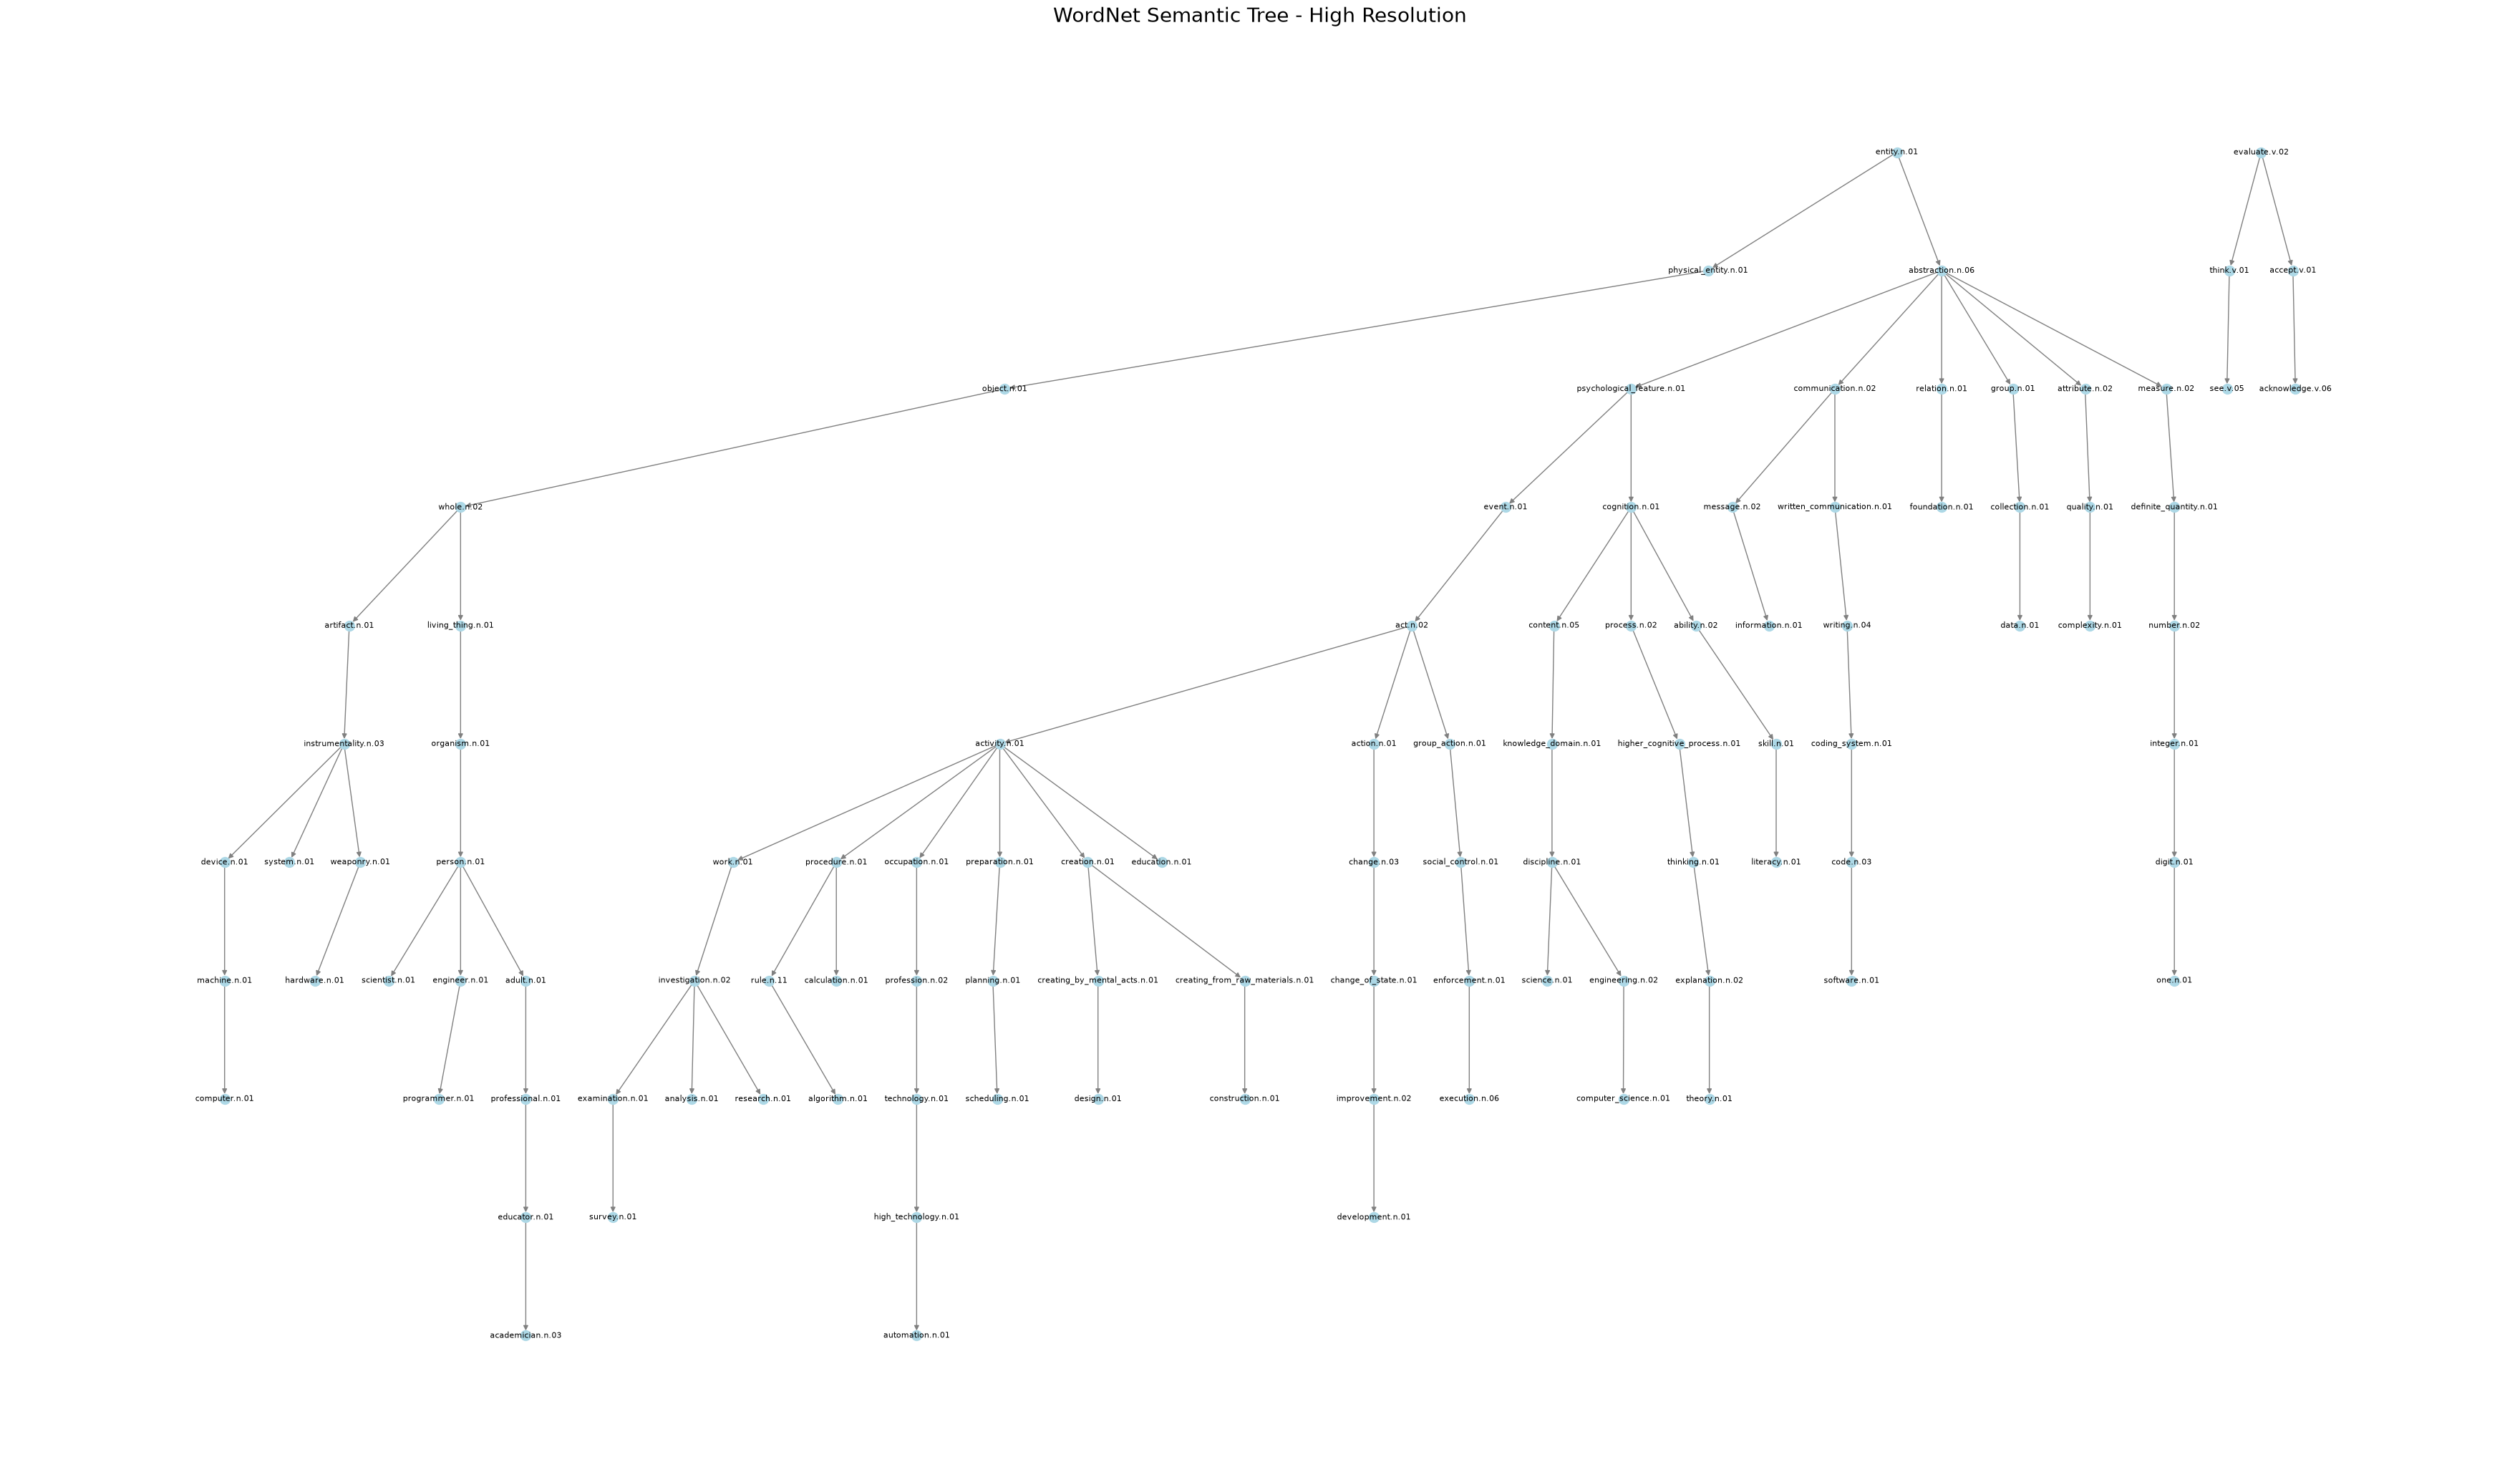

In [17]:
draw_unified_tree()
clean()